In [2]:
import os
print(os.getcwd())
print(os.listdir(".."))          # 看上一層（找工作專題）有哪些資料夾
print(os.listdir("../data"))     # 看 data 裡有沒有 csv

C:\Users\jimbc\Desktop\找工作專題\notebooks
['data', 'models', 'notebooks', 'outputs', 'README.docx', 'requirements.txt.docx', 'src']
['ICU_Data_with_ID_Cleaned.csv']


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1) 讀資料
df = pd.read_csv("../data/ICU_Data_with_ID_Cleaned.csv")

# 2) 移除 id
df = df.drop(columns=["id"])

# 3) target
target_col = "Death"
X = df.drop(columns=[target_col])
y = df[target_col]

# 4) 切 train/test（保持類別比例）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("Death rate (train):", y_train.mean().round(4))
print("Death rate (test) :", y_test.mean().round(4))

Train: (1832, 31) (1832,)
Test : (458, 31) (458,)
Death rate (train): 0.1097
Death rate (test) : 0.1092


In [4]:
# 1️⃣ 計算 train 的缺失比例
missing_ratio = X_train.isnull().mean()

# 2️⃣ 找出高缺失欄位
high_missing_cols = missing_ratio[missing_ratio > 0.5].index.tolist()

print("High missing columns (>50%):")
print(high_missing_cols)

High missing columns (>50%):
['ALT_first', 'Bilirubin_first']


In [5]:
# 同步刪除高缺失欄位
X_train = X_train.drop(columns=high_missing_cols)
X_test  = X_test.drop(columns=high_missing_cols)

print("After drop:")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

After drop:
Train shape: (1832, 29)
Test shape : (458, 29)


In [6]:
# 1️⃣ 特殊欄位規則（先做，不用統計）
if "MechVentDuration" in X_train.columns:
    X_train["MechVentDuration"] = X_train["MechVentDuration"].fillna(0)
    X_test["MechVentDuration"]  = X_test["MechVentDuration"].fillna(0)

if "FiO2_first" in X_train.columns:
    X_train["FiO2_first"] = X_train["FiO2_first"].fillna(0.21)
    X_test["FiO2_first"]  = X_test["FiO2_first"].fillna(0.21)

print("Special columns handled.")

Special columns handled.


In [7]:
import numpy as np

# 找出仍有缺失的欄位（只看 train）
cols_with_na = X_train.columns[X_train.isnull().any()].tolist()

print("Columns with NA before fill:")
print(cols_with_na)

# 1️⃣ 建立 missing indicator（只對仍有 NA 的欄位）
for col in cols_with_na:
    X_train[f"{col}_missing"] = X_train[col].isnull().astype(int)
    X_test[f"{col}_missing"]  = X_test[col].isnull().astype(int)

# 2️⃣ 用 train 的 median 填補（避免資料洩漏）
medians = X_train.median(numeric_only=True)

for col in cols_with_na:
    median_value = medians[col]
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col]  = X_test[col].fillna(median_value)

print("After fill:")
print("Train NA total:", X_train.isnull().sum().sum())
print("Test NA total :", X_test.isnull().sum().sum())

Columns with NA before fill:
['Gender', 'GCS_first', 'HR_first', 'MAP_first', 'SaO2_first', 'SysABP_first', 'GCS_lowest', 'Glucose_lowest', 'HR_lowest', 'MAP_lowest', 'SaO2_lowest', 'Glucose_highest', 'HR_highest', 'MAP_highest', 'Creatinine_first', 'HCO3_first', 'HCT_first', 'K_first', 'Lactate_first', 'Mg_first', 'Platelets_first', 'WBC_first', 'pH_first', 'UrineOutputSum']
After fill:
Train NA total: 0
Test NA total : 0


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# 只對數值欄位標準化
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
recall_lr = recall_score(y_test, y_pred_lr)

print("Logistic Regression")
print("Accuracy:", round(acc_lr,4))
print("AUC:", round(auc_lr,4))
print("Recall:", round(recall_lr,4))

Logistic Regression
Accuracy: 0.8908
AUC: 0.8057
Recall: 0.12


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print("Random Forest")
print("Accuracy:", round(acc_rf,4))
print("AUC:", round(auc_rf,4))
print("Recall:", round(recall_rf,4))

Random Forest
Accuracy: 0.9017
AUC: 0.8115
Recall: 0.1


In [13]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

threshold = 0.2
y_pred_lr_adj = (y_prob_lr >= threshold).astype(int)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)

print("XGBoost")
print("Accuracy:", round(acc_xgb,4))
print("AUC:", round(auc_xgb,4))
print("Recall:", round(recall_xgb,4))

XGBoost
Accuracy: 0.8865
AUC: 0.7893
Recall: 0.14


E:\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:34:05] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


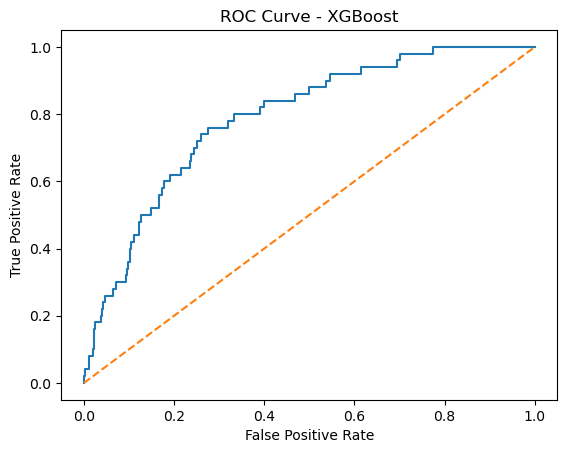

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.show()

In [14]:
threshold = 0.2
y_pred_adj = (y_prob_xgb >= threshold).astype(int)

from sklearn.metrics import accuracy_score, recall_score

print("Threshold:", threshold)
print("Accuracy:", round(accuracy_score(y_test, y_pred_adj),4))
print("Recall:", round(recall_score(y_test, y_pred_adj),4))

Threshold: 0.2
Accuracy: 0.8668
Recall: 0.26


In [15]:
threshold = 0.1
y_pred_adj = (y_prob_xgb >= threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy:", round(accuracy_score(y_test, y_pred_adj),4))
print("Recall:", round(recall_score(y_test, y_pred_adj),4))

Threshold: 0.1
Accuracy: 0.8384
Recall: 0.44


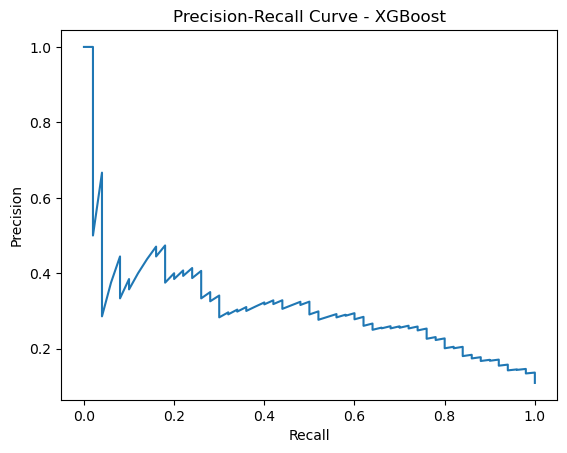

In [16]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.show()

In [17]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", round(best_threshold,4))
print("Best F1 score:", round(best_f1,4))
print("Recall at best F1:", round(recall[best_idx],4))
print("Precision at best F1:", round(precision[best_idx],4))

Best threshold: 0.0329
Best F1 score: 0.3947
Recall at best F1: 0.6
Precision at best F1: 0.2941


In [18]:
threshold = 0.0329
y_pred_final = (y_prob_xgb >= threshold).astype(int)

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

print("Final Threshold:", threshold)
print("Accuracy:", round(accuracy_score(y_test, y_pred_final),4))
print("Recall:", round(recall_score(y_test, y_pred_final),4))
print("Precision:", round(precision_score(y_test, y_pred_final),4))
print("F1:", round(f1_score(y_test, y_pred_final),4))

Final Threshold: 0.0329
Accuracy: 0.7991
Recall: 0.6
Precision: 0.2941
F1: 0.3947


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 取得 feature importance
importances = xgb.feature_importances_
feature_names = X_train.columns

# 建立 dataframe
feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# 排序
feat_df = feat_df.sort_values(by="importance", ascending=False)

# 顯示前 15 名
feat_df.head(15)

,feature,importance
27,MechVentDuration,0.109188
2,Age,0.054128
17,Creatinine_first,0.043192
47,Lactate_first_missing,0.042483
7,SaO2_first,0.041117
22,Lactate_first,0.039603
0,SAPS-I,0.036658
21,K_first,0.034771
13,SaO2_lowest,0.032967
11,HR_lowest,0.032184


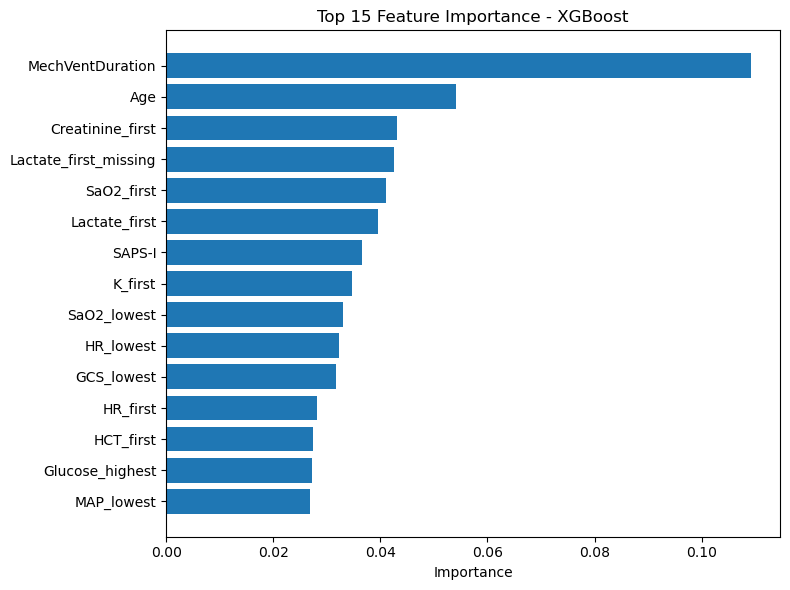

In [20]:
plt.figure(figsize=(8,6))

top_n = 15
plt.barh(
    feat_df["feature"][:top_n][::-1],
    feat_df["importance"][:top_n][::-1]
)

plt.xlabel("Importance")
plt.title("Top 15 Feature Importance - XGBoost")
plt.tight_layout()
plt.show()